# 01_building_dedupe_feature_importance_model
A notebook to explore different ML models aimed at measuring the relative importance of attributes (e.g. DOI, title) when establishing whether two records (academic papers, books) are duplicates of one another. 

### Import Libraries and Configure Paths

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import (
    cross_val_predict,
    cross_val_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# below are the different classifiers we will try out
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sys.path.insert(0, "..")

REPO_DIR = Path.cwd().parent
RAW_DATA = REPO_DIR / "notebooks/data/srsr_data.csv"

## Prepare gold standard dataset
We read in a gold standard dataset (a systematic search dataset containing preclinical systematic reviews, taken from the ASySD evaluation). It contains 53001 records with labelled duplicate groups. We use functions to obtain all of the gold standard duplicate pairs (n=22700 pairs) and "close" non duplicate pairs (n=996200) which match on at least some fiels (according to blocking criteria)

In [3]:
#| output: false

from pathlib import Path

from app.dedupe_old import *

from app.determine_weights import *

df = pd.read_csv(RAW_DATA, encoding="latin-1")
df.columns = [c.replace("ï..", "").strip().lower() for c in df.columns]

dupes = get_gold_standard_dupes(df)
non_dupes = get_gold_standard_close_non_dupes(
    df, id_column="recordid", block_rules=BLOCK_RULES_OLD
)

2026-05-19 08:45:58.963 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:177 - Generating hard negatives from 53001 records using 9 blocking rules
2026-05-19 08:45:58.971 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:182 - Processing rule 1/9: ['title']
2026-05-19 08:46:01.224 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:244 - Rule ('title',): 21572 candidate pairs, 633 valid hard negatives, total negatives so far: 633
2026-05-19 08:46:01.232 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:182 - Processing rule 2/9: ['abstract']
2026-05-19 08:46:06.544 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:244 - Rule ('abstract',): 979 candidate pairs, 24 valid hard negatives, total negatives so far: 657
2026-05-19 08:46:06.546 | INFO     | app.determine_weights:get_gold_standard_close_non_dupes:182 - Processing rule 3/9: ['doi']
2026-05-19 08:46:08.026 | INFO     | app.determine_weigh

We build a complete train/test set using all of the duplicate pairs and a subset of the non-duplicates to arrive at a set with a distribution of 2:1 non-dupe pairs to dupes. We then perform the field specific string comparisons using the deduplication function and save the resulting dataframe output. This takes some time to run, so we can easily load the results of this comparison separately. 

In [ ]:
#| warning: false
#| eval: false
#

training_test_df = build_pre_comparison_training_test_set_df(dupes, non_dupes)
post_comparison = perform_deduplication_on_training_test_set_df(
    training_test_df=training_test_df, gold_standard_df=df
)

In [ ]:
# the data is saved here from a past run
DATA_PATH = REPO_DIR / "notebooks/results/scored_results_algorithm_builder.csv"

### Load and inspect data
We now inspect the data after the string comparisons have been run. For each field, there is a match score between 0-1 and a row_mean column indicates the mean of all match scores. 

In [5]:
test_train_compared_df = pd.read_csv(DATA_PATH)
test_train_compared_df

,Unnamed: 0,id_a,id_b,is_dupe,doi,title,authors,year,journal,pages,abstract,volume,issue
0,0,6,25251,1,1.0,1.000000,1.000000,1.0,1.000000,1.0,0.755385,1.000000,1.0
1,1,17,25280,1,1.0,1.000000,1.000000,1.0,1.000000,1.0,0.964158,1.000000,1.0
2,2,25,25228,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.976696,0.696970,0.8
3,3,26,25288,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.984689,0.803509,0.0
4,4,36,25271,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.979578,0.762963,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68043,68043,3323,45913,0,0.0,0.200000,0.594693,1.0,0.846154,0.0,0.000000,1.000000,0.0
68044,68044,13955,13480,0,0.0,0.230159,0.535837,1.0,0.622222,0.0,0.257487,0.000000,1.0
68045,68045,13319,13351,0,0.0,0.263566,0.359649,1.0,0.535714,0.0,0.270473,0.000000,1.0
68046,68046,2946,4925,0,0.0,0.181818,0.556851,1.0,0.597884,0.0,0.254840,0.000000,1.0


### Build a standard training/eval set
Using all the data, we split into a full feature set (`X`) containing match scores for doi, title, author, year and other meta-data and target labels (`y`) noting whether or not the pairs are duplicates. 

In [6]:
X = test_train_compared_df.drop(columns=["is_dupe", "Unnamed: 0", "id_a", "id_b"])
y = test_train_compared_df["is_dupe"]

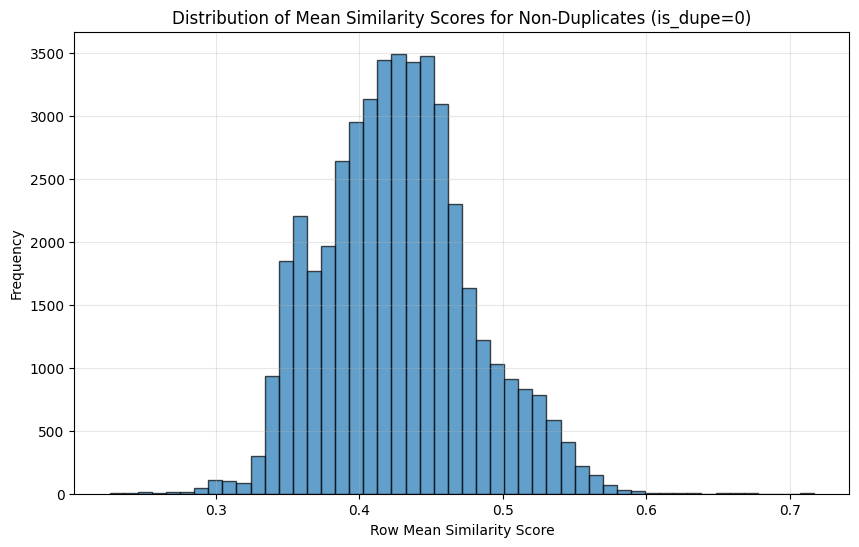

Summary statistics for non-duplicate row means:
count    45359.000000
mean         0.426504
std          0.051775
min          0.225976
25%          0.390175
50%          0.425231
75%          0.457945
max          0.716827
Name: row_mean, dtype: float64


In [7]:
# Create subset where is_dupe==0
non_dupes = test_train_compared_df[test_train_compared_df["is_dupe"] == 0].copy()

# Calculate row means for specified columns
similarity_cols = [
    "doi",
    "title",
    "authors",
    "year",
    "journal",
    "pages",
    "abstract",
    "volume",
    "issue",
]
non_dupes["row_mean"] = non_dupes[similarity_cols].mean(axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(non_dupes["row_mean"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Row Mean Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Similarity Scores for Non-Duplicates (is_dupe=0)")
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print("Summary statistics for non-duplicate row means:")
print(non_dupes["row_mean"].describe())

### Evaluating model performance

We then evaluated a host of different models on this classificaiton task and used **5-fold cross-validation** on the full feature set (`X`) and target labels (`y`).

For every model, we calculate the mean score for four evaluation metrics:

- **accuracy**: overall proportion of correct predictions
- **precision**: when the model predicts "duplicate", how often that prediction is correct
- **recall**: how many of the true duplicates the model successfully finds
- **f1**: a balance between precision and recall

The loop stores one row per **model + metric** combination in `eval_set`, and then converts the results into a DataFrame called `eval_df`.

This gives a quick comparison of baseline performance across all candidate models before any tuning or rule-based adjustments.

In [8]:
knn = KNeighborsClassifier()
svm_linear = SVC(kernel="linear")
svm_default = SVC()
dtree = DecisionTreeClassifier()
naive_bayes = GaussianNB()
random_forest = RandomForestClassifier()
logistic_regression = LogisticRegression(
    multi_class="multinomial", max_iter=10000, solver="sag"
)

In [9]:
folds = 5

In [10]:
models = {
    "knn": knn,
    "svm_linear": svm_linear,
    "svm_default": svm_default,
    "dtree": dtree,
    "naive_bayes": naive_bayes,
    "random_forest": random_forest,
    "logistic_regression": logistic_regression,
}
accuracy_evaluations = ["accuracy", "precision", "recall", "f1"]

In [11]:
eval_set = []
conf_mats = []
for model_name, model in models.items():
    for acc_val in accuracy_evaluations:
        cross_val_prediction = cross_val_predict(model, X, y, cv=folds)
        conf_mats.append({model_name: confusion_matrix(y, cross_val_prediction)})
        acc_standard = np.mean(
            cross_val_score(model, X=X, y=y, cv=folds, verbose=0, scoring=acc_val)
        )
        newline = {
            "model_name": model_name,
            "acc_val": acc_val,
            "standard": acc_standard,
        }
        eval_set.append(newline)

eval_df = pd.DataFrame(eval_set)
eval_df

c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_clas

,model_name,acc_val,standard
0,knn,accuracy,0.999633
1,knn,precision,0.999471
2,knn,recall,0.999427
3,knn,f1,0.999449
4,svm_linear,accuracy,0.999603
5,svm_linear,precision,0.999515
6,svm_linear,recall,0.999295
7,svm_linear,f1,0.999405
8,svm_default,accuracy,0.999662
9,svm_default,precision,0.999471


Using 5-fold cross validation scores from the best performing model (logistic regression), we then build a confusion matrix to compare predicted labels. 

**What matters:**
- **True Negatives & True Positives**: Correct predictions
- **False Positives**: Wrongly flagged as duplicate
- **False Negatives**: Missed duplicates 

We also create a heatmap to visualise the confusion matrix. This indicates 17 false negatives and 10 false positives. 


c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_clas

Text(0.5, 427.9555555555555, 'Predicted label')

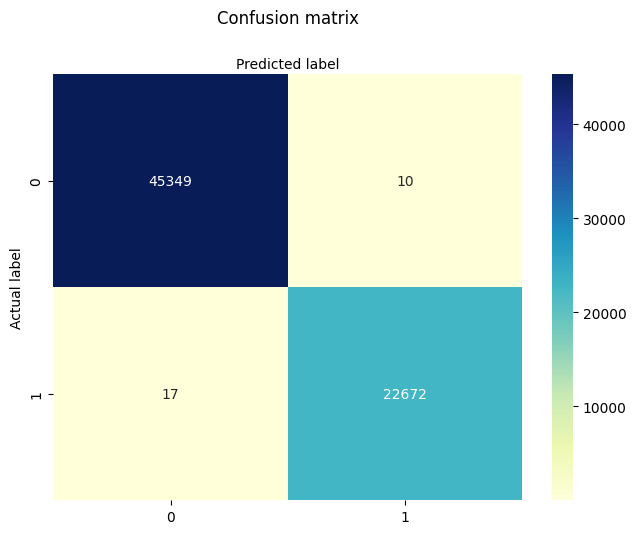

In [12]:
#| warning: false

from sklearn import metrics
from sklearn.model_selection import cross_val_predict

# get cross-validated predictions (avoids passing feature matrix by mistake)
y_pred = cross_val_predict(models["logistic_regression"], X, y, cv=folds)

cnf_matrix = metrics.confusion_matrix(y, y_pred)
cnf_matrix

# import required modules
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

class_names = [0, 1]  # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt="g")
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title("Confusion matrix", y=1.1)
plt.ylabel("Actual label")
plt.xlabel("Predicted label")

We save the logistic regression weights to a .json file to use later in developing the deduper algorithm.

In [13]:
#| warning: false
#| eval: false

import json

# Fit logistic regression on full dataset to extract weights
lr_full = LogisticRegression(multi_class="multinomial", max_iter=10000, solver="sag")
lr_full.fit(X, y)

feature_names = list(X.columns)
coeffs = dict(zip(feature_names, lr_full.coef_[0].tolist()))
intercept = float(lr_full.intercept_[0])

results = {"intercept": intercept, "coeffs": coeffs}

# Display
coeffs_df = pd.DataFrame(
    [
        {"feature": k, "coefficient": v}
        for k, v in sorted(coeffs.items(), key=lambda x: abs(x[1]), reverse=True)
    ]
)
print(f"Intercept: {intercept:.6f}")
display(coeffs_df)

# Save to notebooks/results/
output_dir = REPO_DIR / "notebooks" / "results"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "logistic_coeffs.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {output_path}")

c:\Users\khair\OneDrive - University College London\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Intercept: -8.671311


,feature,coefficient
0,title,6.536214
1,authors,2.584738
2,doi,2.421469
3,journal,1.563933
4,pages,1.161132
5,volume,0.541160
6,year,0.217547
7,abstract,-0.128192
8,issue,-0.059651


Saved to c:\Users\khair\OneDrive - University College London\deduplication-toolkit\notebooks\results\logistic_coeffs.json


### Build a training/eval set with even more "difficult duplicates"
We want to inspect the distribution of mean similarity scores for non-duplicate pairs. To make the classification task more challenging, we then sample the most similar non-duplicates (for example, the top 25% by `row_mean`).

In [ ]:
# Create subset where is_dupe==0
non_dupes = test_train_compared_df[test_train_compared_df["is_dupe"] == 0].copy()

# Calculate row means for specified columns
similarity_cols = [
    "doi",
    "title",
    "authors",
    "year",
    "journal",
    "pages",
    "abstract",
    "volume",
    "issue",
]
non_dupes["row_mean"] = non_dupes[similarity_cols].mean(axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(non_dupes["row_mean"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Row Mean Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Similarity Scores for Non-Duplicates (is_dupe=0)")
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print("Summary statistics for non-duplicate row means:")
print(non_dupes["row_mean"].describe())

We created a subset of our test/train data containing only the top-25% of close non-dupes.

In [ ]:
# Define similarity columns
similarity_cols = [
    "doi",
    "title",
    "authors",
    "year",
    "journal",
    "pages",
    "abstract",
    "volume",
    "issue",
]

# Create row means for the entire dataset
test_train_compared_df["row_mean"] = test_train_compared_df[similarity_cols].mean(
    axis=1
)

# Filter non-duplicates with row_mean > 0.457
non_dupes_filtered = test_train_compared_df[
    (test_train_compared_df["is_dupe"] == 0)
    & (test_train_compared_df["row_mean"] > 0.457)
].copy()

# Keep all duplicates
dupes = test_train_compared_df[test_train_compared_df["is_dupe"] == 1].copy()

# Calculate target counts for 2/3 non-dupes and 1/3 dupes
n_dupes = len(dupes)
n_non_dupes_needed = n_dupes * 2  # 2/3 of total means 2x the number of dupes

# Sample non-duplicates (or use all if we don't have enough)
if len(non_dupes_filtered) >= n_non_dupes_needed:
    non_dupes_sampled = non_dupes_filtered.sample(
        n=n_non_dupes_needed, replace=False, random_state=42
    )
else:
    non_dupes_sampled = non_dupes_filtered
    print(
        f"Warning: Only {len(non_dupes_filtered)} non-dupes available, needed {n_non_dupes_needed}"
    )

# Combine and shuffle
higher_threshold_df = pd.concat([non_dupes_sampled, dupes], ignore_index=True)
higher_threshold_df = higher_threshold_df.sample(frac=1, random_state=42).reset_index(
    drop=True
)

X_higher = higher_threshold_df.drop(
    columns=["is_dupe", "row_id", "Unnamed: 0", "id_a", "id_b"]
)
y_higher = higher_threshold_df["is_dupe"]

### Evaluating difficult dups model performance

In this cell, each model is tested using **5-fold cross-validation** on the full feature set (`X_higher`) and target labels (`y_higher`) for out dataset with a higher similarity threshold to understand how it influences performance. 

For every model, we calculate the mean score for four evaluation metrics:

- **accuracy**: overall proportion of correct predictions
- **precision**: when the model predicts "duplicate", how often that prediction is correct
- **recall**: how many of the true duplicates the model successfully finds
- **f1**: a balance between precision and recall

The loop stores one row per **model + metric** combination in `eval_set`, and then converts the results into a DataFrame called `eval_df`.

This gives a quick comparison of baseline performance across all candidate models before any tuning or rule-based adjustments.

In [ ]:
#| warning: false

eval_set = []
for model_name, model in models.items():
    for acc_val in accuracy_evaluations:
        acc_higher = np.mean(
            cross_val_score(
                model, X=X_higher, y=y_higher, cv=folds, verbose=0, scoring=acc_val
            )
        )
        newline = {
            "model_name": model_name,
            "acc_val": acc_val,
            "higher_threshold": acc_higher,
        }
        eval_set.append(newline)

eval_df = pd.DataFrame(eval_set)
eval_df

c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper b

,model_name,acc_val,higher_threshold
0,knn,accuracy,0.999475
1,knn,precision,0.999515
2,knn,recall,0.999691
3,knn,f1,0.999603
4,svm_linear,accuracy,0.999300
5,svm_linear,precision,0.999603
6,svm_linear,recall,0.999339
7,svm_linear,f1,0.999471
8,svm_default,accuracy,0.999650
9,svm_default,precision,0.999603


## Inspecting errors
We want to understand where the false positives and false negatives are coming from and improve the model further. Importantly, we want to reduce the false positives down to the absolute minimum, even if that means some loss in sensitivity. 

We first focus on the false positives and write a CSV file for manual inspection.

In [ ]:
# Identify false positives: predicted=1 (duplicate) but actual=0 (non-duplicate)
# Using plain logistic regression predictions (no rules layer)
false_positive_mask = (y_pred_lr == 1) & (y == 0)
n_false_positives = false_positive_mask.sum()

print(f"Total False Positives: {n_false_positives}")
print(f"False Positive Rate: {n_false_positives / (cm_lr[0, 0] + cm_lr[0, 1]):.2%}\n")

if n_false_positives > 0:
    fp_indices = np.where(false_positive_mask)[0]
    fp_data = test_train_compared_df.iloc[fp_indices].copy()
    fp_data["pred_proba_lr"] = y_proba_lr[fp_indices]

    # --- Raw data lookup for false positives ---
    raw_cols = [
        "RecordID",
        "Title",
        "Author",
        "Year",
        "DOI",
        "Journal",
        "Abstract",
        "Pages",
        "Volume",
        "Number",
        "ISBN",
    ]
    raw_cols_present = [c for c in raw_cols if c in raw_df.columns]

    fp_raw_rows = []
    for _, fp_row in fp_data.iterrows():
        for side, record_id in [("A", fp_row["id_a"]), ("B", fp_row["id_b"])]:
            raw_record = raw_df[raw_df["RecordID"] == record_id][raw_cols_present]
            if not raw_record.empty:
                row_dict = raw_record.iloc[0].to_dict()
                row_dict["side"] = side
                row_dict["pair_index"] = fp_row.name
                row_dict["pred_proba_lr"] = fp_row["pred_proba_lr"]
                fp_raw_rows.append(row_dict)

    fp_raw_df = pd.DataFrame(fp_raw_rows)
    display_cols = ["pair_index", "side", "pred_proba_lr"] + raw_cols_present
    display_cols = [c for c in display_cols if c in fp_raw_df.columns]
    fp_raw_df = fp_raw_df[display_cols].sort_values(
        ["pred_proba_lr", "pair_index"], ascending=[False, True]
    )
    fp_raw_df

else:
    print("No false positives found!")

Path("results").mkdir(exist_ok=True)
fp_raw_df.to_csv("notebooks/results/fp_raw_df.csv", index=False)

We then write a CSV file with the false negatives for manual inspection.

In [ ]:
# Identify false positives: predicted=1 (duplicate) but actual=0 (non-duplicate)
# Using plain logistic regression predictions (no rules layer)
false_positive_mask = (y_pred_lr == 1) & (y == 0)
n_false_positives = false_positive_mask.sum()

print(f"Total False Positives: {n_false_positives}")
print(f"False Positive Rate: {n_false_positives / (cm_lr[0, 0] + cm_lr[0, 1]):.2%}\n")

if n_false_positives > 0:
    fp_indices = np.where(false_positive_mask)[0]
    fp_data = test_train_compared_df.iloc[fp_indices].copy()
    fp_data["pred_proba_lr"] = y_proba_lr[fp_indices]

    # --- Raw data lookup for false positives ---
    raw_cols = [
        "RecordID",
        "Title",
        "Author",
        "Year",
        "DOI",
        "Journal",
        "Abstract",
        "Pages",
        "Volume",
        "Number",
        "ISBN",
    ]
    raw_cols_present = [c for c in raw_cols if c in raw_df.columns]

    fp_raw_rows = []
    for _, fp_row in fp_data.iterrows():
        for side, record_id in [("A", fp_row["id_a"]), ("B", fp_row["id_b"])]:
            raw_record = raw_df[raw_df["RecordID"] == record_id][raw_cols_present]
            if not raw_record.empty:
                row_dict = raw_record.iloc[0].to_dict()
                row_dict["side"] = side
                row_dict["pair_index"] = fp_row.name
                row_dict["pred_proba_lr"] = fp_row["pred_proba_lr"]
                fp_raw_rows.append(row_dict)

    fp_raw_df = pd.DataFrame(fp_raw_rows)
    display_cols = ["pair_index", "side", "pred_proba_lr"] + raw_cols_present
    display_cols = [c for c in display_cols if c in fp_raw_df.columns]
    fp_raw_df = fp_raw_df[display_cols].sort_values(
        ["pred_proba_lr", "pair_index"], ascending=[False, True]
    )
    fp_raw_df

else:
    print("No false positives found!")

Path("results").mkdir(exist_ok=True)
fp_raw_df.to_csv("results/fp_raw_df.csv", index=False)

## Experimentation - removing the DOI column
Is there too much reliance on certain metadata fields here? We wanted to try removing the DOI and running the models again to check on the results. 

In [128]:
# X_no_doi = test_train_compared_df.drop(columns=['is_dupe', 'Unnamed: 0', 'id_a', 'id_b', 'doi', 'row_mean'])
X_no_doi = test_train_compared_df.drop(
    columns=[
        "is_dupe",
        "Unnamed: 0",
        "id_a",
        "id_b",
        "doi",
    ]
)
y_no_doi = test_train_compared_df["is_dupe"]

In [ ]:
#| warning: false

eval_set_no_doi = []
for model_name, model in models.items():
    for acc_val in accuracy_evaluations:
        acc_no_doi = np.mean(
            cross_val_score(
                model, X=X_no_doi, y=y_no_doi, cv=folds, verbose=0, scoring=acc_val
            )
        )
        newline = {
            "model_name": model_name,
            "acc_val": acc_val,
            "no_doi": acc_no_doi,
        }
        eval_set_no_doi.append(newline)

eval_no_doi_df = pd.DataFrame(eval_set_no_doi)
eval_no_doi_df

c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper b

,model_name,acc_val,no_doi
0,knn,accuracy,0.999647
1,knn,precision,0.999383
2,knn,recall,0.999559
3,knn,f1,0.999471
4,svm_linear,accuracy,0.999530
5,svm_linear,precision,0.999427
6,svm_linear,recall,0.999163
7,svm_linear,f1,0.999295
8,svm_default,accuracy,0.999633
9,svm_default,precision,0.999339


these values again are weirdly high, even though we've omitted DOI and the row_means from X. so what is going on here? 

In [130]:
models["random_forest"].fit(X_no_doi, y_no_doi)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
np.round(models["random_forest"].feature_importances_, decimals=3)

array([0.445, 0.202, 0.   , 0.067, 0.017, 0.004, 0.012, 0.001, 0.252])

In [132]:
X_no_doi.columns

Index(['title', 'authors', 'year', 'journal', 'pages', 'abstract', 'volume',
       'issue', 'row_mean'],
      dtype='object')

does this make sense? 

In [149]:
y_pred_no_doi = models["random_forest"].predict(X_no_doi)

In [150]:
sum(y_no_doi == y_pred_no_doi) == len(y_no_doi)

True